# 05 - Classical Facility-Location Benchmark Models (V3)

This notebook establishes four exact OR benchmarks for the Hajj medical-drone project: **p-median, p-center, MCLP, and LSCP**.

Experiments compare uniform versus OSM-informed proxy demand, multiple numbers of hubs `p`, multiple assumed drone service ranges, and a 5 km range-constrained p-median. Models use **Pyomo + HiGHS**.

In [1]:
# If needed:
# %pip install -U pyomo highspy pandas numpy folium plotly
from pathlib import Path
import time, numpy as np, pandas as pd, pyomo.environ as pyo
import plotly.express as px, folium
from branca.element import Element
PROJECT_ROOT=Path("hajj_drone_project")
MODEL_DIR=PROJECT_ROOT/"data"/"model"; MAP_DIR=PROJECT_ROOT/"outputs"/"maps"; REPORT_DIR=PROJECT_ROOT/"outputs"/"reports"
for p in [MODEL_DIR,MAP_DIR,REPORT_DIR]: p.mkdir(parents=True,exist_ok=True)
P_VALUES=[1,2,3,4,5,6,8,10]; RANGE_VALUES_KM=[2.5,5.0,7.5,10.0]; BASELINE_RANGE_KM=5.0
solver=pyo.SolverFactory("highs")
if not solver.available(exception_flag=False): raise RuntimeError("Install with: %pip install -U highspy pyomo")

## 1. Load Notebook 04 outputs

In [2]:
demand_file=MODEL_DIR/"baseline_500m_demand_points_with_nearest_hub_v1.csv"
hub_file=MODEL_DIR/"candidate_drone_hubs_v1.csv"
distance_file=MODEL_DIR/"demand_to_candidate_hub_air_distance_km_v1.csv"

for f in [demand_file,hub_file,distance_file]:
    if not f.exists():
        raise FileNotFoundError(f"Missing {f}. Run Notebook 04 first.")

demand=pd.read_csv(demand_file)
hubs=pd.read_csv(hub_file)
distance_df=pd.read_csv(distance_file,index_col=0)

# Remove accidental CSV index columns.
for df in [demand,hubs]:
    bad=[c for c in df.columns if str(c).lower().startswith("unnamed:")]
    if bad:
        df.drop(columns=bad,inplace=True)

# Align demand points exactly with matrix rows.
demand=(demand.set_index("demand_point_id")
        .loc[distance_df.index]
        .reset_index())

# Matrix columns are the authoritative hub IDs and order.
matrix_hub_ids=list(distance_df.columns)

if len(hubs)!=len(matrix_hub_ids):
    raise ValueError(
        f"Hub CSV has {len(hubs)} rows but distance matrix has "
        f"{len(matrix_hub_ids)} hub columns."
    )

if "hub_id" not in hubs.columns:
    print("hub_id missing from hub CSV; reconstructing from distance matrix.")
    hubs.insert(0,"hub_id",matrix_hub_ids)
elif hubs["hub_id"].astype(str).tolist()!=matrix_hub_ids:
    hubs=(hubs.set_index("hub_id")
          .loc[matrix_hub_ids]
          .reset_index())

D=distance_df.to_numpy(float)
I=list(range(len(demand)))
J=list(range(len(hubs)))

WEIGHTS={
    "uniform":demand["demand_weight_uniform"].to_numpy(float),
    "proxy":demand["proxy_demand_weight"].to_numpy(float)
}

assert D.shape==(len(demand),len(hubs))
assert "hub_id" in hubs.columns

print("Demand:",len(I))
print("Hubs:",len(J))
print("Matrix:",D.shape)
print("\nFirst hub IDs:")
print(hubs["hub_id"].head())
print("\nHub categories:")
print(hubs["category"].value_counts())


Demand: 556
Hubs: 59
Matrix: (556, 59)

First hub IDs:
0    HUB_001
1    HUB_002
2    HUB_003
3    HUB_004
4    HUB_005
Name: hub_id, dtype: object

Hub categories:
category
hospital                  53
seasonal_health_center     5
ambulance_station          1
Name: count, dtype: int64


## 2. Model functions

In [4]:
def run(m):
    t=time.perf_counter()
    r=solver.solve(m,load_solutions=False)
    sec=time.perf_counter()-t
    term=str(r.solver.termination_condition)
    if term.lower()=="optimal":
        try:
            m.solutions.load_from(r)
        except Exception:
            try:
                r.solution_loader.load_vars()
            except Exception:
                pass
    return sec,term

def hub_string(sel):
    if len(sel) == 0:
        return ""

    return ";".join(
        hubs.iloc[sel]["hub_id"]
        .astype(str)
        .tolist()
    )

def assignment_metrics(a,w):
    d=D[np.arange(len(I)),a]
    return float(d.mean()),float(np.average(d,weights=w)),float(d.max())

def solve_pmedian(p,scenario="proxy",rng=None):
    w=WEIGHTS[scenario]; m=pyo.ConcreteModel()
    m.I=pyo.RangeSet(0,len(I)-1); m.J=pyo.RangeSet(0,len(J)-1)
    m.x=pyo.Var(m.I,m.J,domain=pyo.Binary); m.y=pyo.Var(m.J,domain=pyo.Binary)
    m.obj=pyo.Objective(expr=sum(float(w[i])*float(D[i,j])*m.x[i,j] for i in I for j in J))
    m.a=pyo.Constraint(m.I,rule=lambda m,i:sum(m.x[i,j] for j in m.J)==1)
    m.l=pyo.Constraint(m.I,m.J,rule=lambda m,i,j:m.x[i,j]<=m.y[j])
    m.p=pyo.Constraint(expr=sum(m.y[j] for j in m.J)==p)
    if rng is not None:
        m.r=pyo.ConstraintList()
        for i in I:
            for j in J:
                if D[i,j]>rng: m.r.add(m.x[i,j]==0)
    sec,term=run(m)
    if term.lower()!="optimal":
        return {"model":"p-median","demand_scenario":scenario,"p":p,"range_km":rng,
                "objective":np.nan,"mean_distance_km":np.nan,"weighted_mean_distance_km":np.nan,
                "max_distance_km":np.nan,"solve_time_s":sec,"termination":term,
                "selected_hubs":""},[],None
    sel=[j for j in J if pyo.value(m.y[j])>.5]
    a=np.array([max(J,key=lambda j:pyo.value(m.x[i,j])) for i in I])
    mean,wmean,mx=assignment_metrics(a,w)
    return {"model":"p-median","demand_scenario":scenario,"p":p,"range_km":rng,
            "objective":pyo.value(m.obj),"mean_distance_km":mean,"weighted_mean_distance_km":wmean,
            "max_distance_km":mx,"solve_time_s":sec,"termination":term,"selected_hubs":hub_string(sel)},sel,a

def solve_pcenter(p):
    m=pyo.ConcreteModel(); m.I=pyo.RangeSet(0,len(I)-1); m.J=pyo.RangeSet(0,len(J)-1)
    m.x=pyo.Var(m.I,m.J,domain=pyo.Binary); m.y=pyo.Var(m.J,domain=pyo.Binary); m.z=pyo.Var(domain=pyo.NonNegativeReals)
    m.obj=pyo.Objective(expr=m.z); m.a=pyo.Constraint(m.I,rule=lambda m,i:sum(m.x[i,j] for j in m.J)==1)
    m.l=pyo.Constraint(m.I,m.J,rule=lambda m,i,j:m.x[i,j]<=m.y[j]); m.p=pyo.Constraint(expr=sum(m.y[j] for j in m.J)==p)
    m.w=pyo.Constraint(m.I,rule=lambda m,i:sum(float(D[i,j])*m.x[i,j] for j in m.J)<=m.z)
    sec,term=run(m)
    if term.lower()!="optimal":
        return {"model":"p-center","demand_scenario":"distance_equity","p":p,"range_km":np.nan,
                "objective":np.nan,"mean_distance_km":np.nan,"weighted_mean_distance_km":np.nan,
                "max_distance_km":np.nan,"solve_time_s":sec,"termination":term,
                "selected_hubs":""},[],None
    sel=[j for j in J if pyo.value(m.y[j])>.5]
    a=np.array([max(J,key=lambda j:pyo.value(m.x[i,j])) for i in I]); mean,wmean,mx=assignment_metrics(a,WEIGHTS["proxy"])
    return {"model":"p-center","demand_scenario":"distance_equity","p":p,"range_km":np.nan,"objective":pyo.value(m.obj),
            "mean_distance_km":mean,"weighted_mean_distance_km":wmean,"max_distance_km":mx,
            "solve_time_s":sec,"termination":term,"selected_hubs":hub_string(sel)},sel,a

def solve_mclp(p,rng,scenario="proxy"):
    w=WEIGHTS[scenario]; cover={i:[j for j in J if D[i,j]<=rng] for i in I}
    m=pyo.ConcreteModel(); m.I=pyo.RangeSet(0,len(I)-1); m.J=pyo.RangeSet(0,len(J)-1)
    m.y=pyo.Var(m.J,domain=pyo.Binary); m.z=pyo.Var(m.I,domain=pyo.Binary)
    m.obj=pyo.Objective(expr=sum(float(w[i])*m.z[i] for i in I),sense=pyo.maximize)
    m.p=pyo.Constraint(expr=sum(m.y[j] for j in m.J)==p)
    m.c=pyo.Constraint(m.I,rule=lambda m,i:m.z[i]<=sum(m.y[j] for j in cover[i]) if cover[i] else m.z[i]==0)
    sec,term=run(m)
    if term.lower()!="optimal":
        return {"model":"MCLP","demand_scenario":scenario,"p":p,"range_km":rng,
                "objective":np.nan,"geographic_coverage_pct":np.nan,"weighted_coverage_pct":np.nan,
                "solve_time_s":sec,"termination":term,"selected_hubs":""},[],None
    sel=[j for j in J if pyo.value(m.y[j])>.5]
    covered=np.array([pyo.value(m.z[i])>.5 for i in I])
    return {"model":"MCLP","demand_scenario":scenario,"p":p,"range_km":rng,"objective":pyo.value(m.obj),
            "geographic_coverage_pct":100*covered.mean(),"weighted_coverage_pct":100*np.sum(w*covered)/np.sum(w),
            "solve_time_s":sec,"termination":term,"selected_hubs":hub_string(sel)},sel,covered

def solve_lscp(rng):
    cover={i:[j for j in J if D[i,j]<=rng] for i in I}; bad=[i for i in I if not cover[i]]
    if bad: return {"model":"LSCP","demand_scenario":"complete_coverage","p":np.nan,"range_km":rng,
                    "termination":"infeasible_precheck","uncoverable_points":len(bad),"selected_hubs":""},[],bad
    m=pyo.ConcreteModel(); m.J=pyo.RangeSet(0,len(J)-1); m.y=pyo.Var(m.J,domain=pyo.Binary)
    m.obj=pyo.Objective(expr=sum(m.y[j] for j in m.J)); m.c=pyo.ConstraintList()
    for i in I: m.c.add(sum(m.y[j] for j in cover[i])>=1)
    sec,term=run(m)
    if term.lower()!="optimal":
        return {"model":"LSCP","demand_scenario":"complete_coverage","p":np.nan,"range_km":rng,
                "objective":np.nan,"solve_time_s":sec,"termination":term,
                "uncoverable_points":0,"selected_hubs":""},[],[]
    sel=[j for j in J if pyo.value(m.y[j])>.5]
    return {"model":"LSCP","demand_scenario":"complete_coverage","p":len(sel),"range_km":rng,"objective":len(sel),
            "solve_time_s":sec,"termination":term,"uncoverable_points":0,"selected_hubs":hub_string(sel)},sel,[]

## 3. Run benchmark suite

This solves 108 MILPs. If you want a quick test first, temporarily set `P_VALUES=[3,5]` and `RANGE_VALUES_KM=[2.5,5.0]`.

In [5]:
results=[]; solutions={}
for s in ["uniform","proxy"]:
    for p in P_VALUES:
        for rng in [None,BASELINE_RANGE_KM]:
            met,sel,a=solve_pmedian(p,s,rng); results.append(met); solutions[("pmedian",s,p,rng)]={"selected":sel,"assign":a}
            print("p-median",s,p,rng,met["termination"])
for p in P_VALUES:
    met,sel,a=solve_pcenter(p); results.append(met); solutions[("pcenter",p)]={"selected":sel,"assign":a}; print("p-center",p,met["termination"])
for s in ["uniform","proxy"]:
    for rng in RANGE_VALUES_KM:
        for p in P_VALUES:
            met,sel,c=solve_mclp(p,rng,s); results.append(met); solutions[("mclp",s,p,rng)]={"selected":sel,"covered":c}
            print("MCLP",s,p,rng,met["termination"])
for rng in RANGE_VALUES_KM:
    met,sel,b=solve_lscp(rng); results.append(met); solutions[("lscp",rng)]={"selected":sel,"uncovered":b}; print("LSCP",rng,met["termination"])
results_df=pd.DataFrame(results)
print("Runs:",len(results_df)); display(results_df.head())

p-median uniform 1 None optimal
p-median uniform 1 5.0 infeasible
p-median uniform 2 None optimal
p-median uniform 2 5.0 infeasible
p-median uniform 3 None optimal
p-median uniform 3 5.0 optimal
p-median uniform 4 None optimal
p-median uniform 4 5.0 optimal
p-median uniform 5 None optimal
p-median uniform 5 5.0 optimal
p-median uniform 6 None optimal
p-median uniform 6 5.0 optimal
p-median uniform 8 None optimal
p-median uniform 8 5.0 optimal
p-median uniform 10 None optimal
p-median uniform 10 5.0 optimal
p-median proxy 1 None optimal
p-median proxy 1 5.0 infeasible
p-median proxy 2 None optimal
p-median proxy 2 5.0 infeasible
p-median proxy 3 None optimal
p-median proxy 3 5.0 optimal
p-median proxy 4 None optimal
p-median proxy 4 5.0 optimal
p-median proxy 5 None optimal
p-median proxy 5 5.0 optimal
p-median proxy 6 None optimal
p-median proxy 6 5.0 optimal
p-median proxy 8 None optimal
p-median proxy 8 5.0 optimal
p-median proxy 10 None optimal
p-median proxy 10 5.0 optimal
p-center

,model,demand_scenario,p,range_km,objective,mean_distance_km,weighted_mean_distance_km,max_distance_km,solve_time_s,termination,selected_hubs,geographic_coverage_pct,weighted_coverage_pct,uncoverable_points
0,p-median,uniform,1.0,NaN,3812.309768,6.856672,6.856672,14.322570,544.694671,optimal,HUB_058,NaN,NaN,NaN
1,p-median,uniform,1.0,5.0,NaN,NaN,NaN,NaN,3.956985,infeasible,,NaN,NaN,NaN
2,p-median,uniform,2.0,NaN,2187.397550,3.934168,3.934168,7.977337,9.578773,optimal,HUB_007;HUB_014,NaN,NaN,NaN
3,p-median,uniform,2.0,5.0,NaN,NaN,NaN,NaN,5.340513,infeasible,,NaN,NaN,NaN
4,p-median,uniform,3.0,NaN,1432.990269,2.577321,2.577321,4.779377,7.205399,optimal,HUB_006;HUB_015;HUB_039,NaN,NaN,NaN


## 4. p-median results

,demand_scenario,p,weighted_mean_distance_km,max_distance_km,solve_time_s,selected_hubs
0,uniform,1.0,6.856672,14.322570,544.694671,HUB_058
2,uniform,2.0,3.934168,7.977337,9.578773,HUB_007;HUB_014
4,uniform,3.0,2.577321,4.779377,7.205399,HUB_006;HUB_015;HUB_039
6,uniform,4.0,2.319102,4.254537,6.873792,HUB_015;HUB_039;HUB_041;HUB_045
8,uniform,5.0,2.121818,4.704866,6.910322,HUB_018;HUB_039;HUB_041;HUB_043;HUB_045
10,uniform,6.0,1.963392,3.940874,7.026576,HUB_014;HUB_018;HUB_039;HUB_042;HUB_043;HUB_045
12,uniform,8.0,1.783190,3.940874,7.111702,HUB_014;HUB_018;HUB_036;HUB_039;HUB_042;HUB_04...
14,uniform,10.0,1.624863,3.833639,6.028010,HUB_014;HUB_016;HUB_017;HUB_018;HUB_036;HUB_03...
16,proxy,1.0,6.348224,14.614218,534.498345,HUB_012
18,proxy,2.0,3.869103,7.977337,9.669491,HUB_007;HUB_014


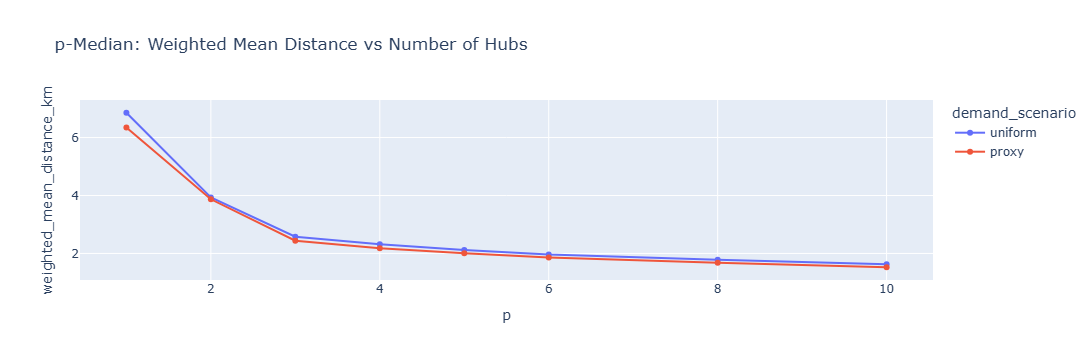

In [6]:
pm=results_df[(results_df.model=="p-median") & results_df.range_km.isna()].copy()
display(pm[["demand_scenario","p","weighted_mean_distance_km","max_distance_km","solve_time_s","selected_hubs"]])
px.line(pm,x="p",y="weighted_mean_distance_km",color="demand_scenario",markers=True,
title="p-Median: Weighted Mean Distance vs Number of Hubs").show()

## 5. p-center results

,p,mean_distance_km,weighted_mean_distance_km,max_distance_km,selected_hubs
32,1.0,6.868436,6.479118,13.318724,HUB_006
33,2.0,4.051057,3.967748,7.977337,HUB_014;HUB_036
34,3.0,2.577542,2.453890,4.779377,HUB_006;HUB_039;HUB_056
35,4.0,2.401816,2.294126,4.248113,HUB_015;HUB_038;HUB_045;HUB_054
36,5.0,2.367358,2.262388,3.954521,HUB_018;HUB_039;HUB_045;HUB_056;HUB_058
37,6.0,2.198863,2.097283,3.833639,HUB_004;HUB_016;HUB_039;HUB_045;HUB_049;HUB_058
38,8.0,2.113166,2.014676,3.729252,HUB_006;HUB_018;HUB_039;HUB_042;HUB_047;HUB_04...
39,10.0,2.259265,2.236107,3.729252,HUB_018;HUB_038;HUB_039;HUB_042;HUB_043;HUB_04...


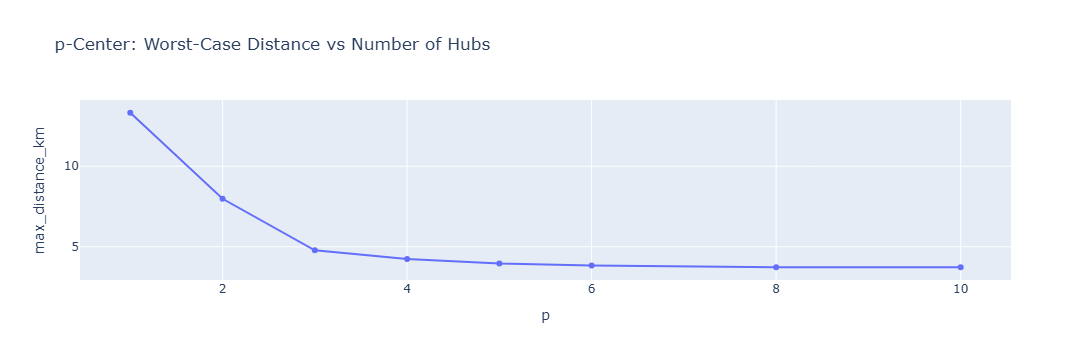

In [7]:
pc=results_df[results_df.model=="p-center"].copy()
display(pc[["p","mean_distance_km","weighted_mean_distance_km","max_distance_km","selected_hubs"]])
px.line(pc,x="p",y="max_distance_km",markers=True,title="p-Center: Worst-Case Distance vs Number of Hubs").show()

## 6. MCLP and LSCP results

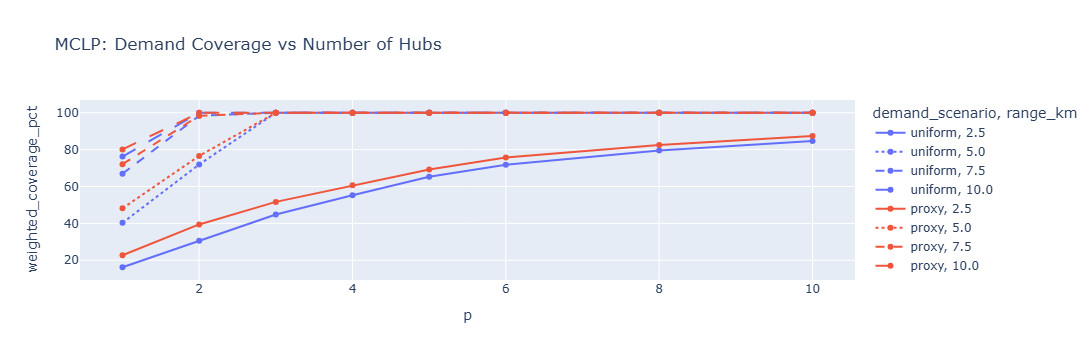

,range_km,p,termination,uncoverable_points,selected_hubs
104,2.5,NaN,infeasible_precheck,47.0,
105,5.0,3.0,optimal,0.0,HUB_006;HUB_007;HUB_016
106,7.5,3.0,optimal,0.0,HUB_007;HUB_047;HUB_048
107,10.0,2.0,optimal,0.0,HUB_047;HUB_054


In [8]:
mc=results_df[results_df.model=="MCLP"].copy()
px.line(mc,x="p",y="weighted_coverage_pct",color="demand_scenario",line_dash="range_km",markers=True,
title="MCLP: Demand Coverage vs Number of Hubs").show()
ls=results_df[results_df.model=="LSCP"].copy()
display(ls[["range_km","p","termination","uncoverable_points","selected_hubs"]])

## 7. Cross-model summary

In [9]:
rows=[]
for p in P_VALUES:
    row={"p":p}
    q=results_df[(results_df.model=="p-median")&(results_df.demand_scenario=="proxy")&results_df.range_km.isna()&(results_df.p==p)]
    if len(q): row["pmedian_proxy_weighted_mean_km"]=q.iloc[0].weighted_mean_distance_km
    q=results_df[(results_df.model=="p-center")&(results_df.p==p)]
    if len(q): row["pcenter_worst_km"]=q.iloc[0].max_distance_km
    q=results_df[(results_df.model=="MCLP")&(results_df.demand_scenario=="proxy")&(results_df.range_km==5)&(results_df.p==p)]
    if len(q): row["mclp_proxy_coverage_5km_pct"]=q.iloc[0].weighted_coverage_pct
    rows.append(row)
cross_model_summary=pd.DataFrame(rows); display(cross_model_summary)

,p,pmedian_proxy_weighted_mean_km,pcenter_worst_km,mclp_proxy_coverage_5km_pct
0,1,6.348224,13.318724,48.164661
1,2,3.869103,7.977337,76.562364
2,3,2.440699,4.779377,100.000000
3,4,2.177170,4.248113,100.000000
4,5,2.007293,3.954521,100.000000
5,6,1.861917,3.833639,100.000000
6,8,1.675662,3.729252,100.000000
7,10,1.522619,3.729252,100.000000


## 8. Map example: proxy p-median, p=5, 5 km limit

In [10]:
key=("pmedian","proxy",5,5.0)
sol=solutions[key]

if sol["assign"] is None:
    print("This p-median scenario is infeasible; no assignment map can be drawn.")
else:
    sel=sol["selected"]; a=sol["assign"]
    m=folium.Map(location=[demand.centroid_lat.mean(),demand.centroid_lon.mean()],zoom_start=11,control_scale=True)
    for i in I:
        j=int(a[i])
        folium.PolyLine(
            [(demand.iloc[i].centroid_lat,demand.iloc[i].centroid_lon),
             (hubs.iloc[j].latitude,hubs.iloc[j].longitude)],
            weight=.6,opacity=.15
        ).add_to(m)
    for j in sel:
        r=hubs.iloc[j]
        folium.CircleMarker(
            [r.latitude,r.longitude],radius=9,color="black",
            fill=True,fill_opacity=.9,
            tooltip=f"{r.hub_id}: {r.map_name}"
        ).add_to(m)
    path=MAP_DIR/"benchmark_pmedian_proxy_p5_range5km.html"
    m.save(path)
    print("Saved:",path)
    display(m)


Saved: hajj_drone_project\outputs\maps\benchmark_pmedian_proxy_p5_range5km.html


## 9. Export results

In [11]:
results_df.to_csv(REPORT_DIR/"classical_facility_location_benchmark_results_v1.csv",index=False,encoding="utf-8-sig")
cross_model_summary.to_csv(REPORT_DIR/"classical_facility_location_cross_model_summary_v1.csv",index=False,encoding="utf-8-sig")
print("Exports complete.")

Exports complete.


In [12]:
# ============================================================
# SAVE DETAILED OPTIMIZATION SOLUTIONS
# ============================================================
#
# This cell preserves the in-memory `solutions` dictionary so
# that maps, tables, and analyses can be recreated later without
# rerunning all optimization models.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

SOLUTION_DIR = MODEL_DIR / "optimization_solutions"
SOLUTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Saving detailed solutions to:")
print(SOLUTION_DIR.resolve())


# ============================================================
# 1. SELECTED HUBS FOR EVERY SOLUTION
# ============================================================

selected_hub_records = []

for key, sol in solutions.items():

    model_type = key[0]

    # --------------------------------------------------------
    # Decode experiment key
    # --------------------------------------------------------

    if model_type == "pmedian":

        _, scenario, p, rng = key

        model_name = "p-median"
        demand_scenario = scenario
        range_km = rng

    elif model_type == "pcenter":

        _, p = key

        model_name = "p-center"
        demand_scenario = "distance_equity"
        range_km = np.nan

    elif model_type == "mclp":

        _, scenario, p, rng = key

        model_name = "MCLP"
        demand_scenario = scenario
        range_km = rng

    elif model_type == "lscp":

        _, rng = key

        model_name = "LSCP"
        demand_scenario = "complete_coverage"
        range_km = rng

        # LSCP determines p itself
        p = len(sol.get("selected", []))

    else:
        continue


    # --------------------------------------------------------
    # Selected hubs
    # --------------------------------------------------------

    selected = sol.get(
        "selected",
        []
    )

    for hub_index in selected:

        hub_row = hubs.iloc[int(hub_index)]

        selected_hub_records.append({

            "model":
                model_name,

            "demand_scenario":
                demand_scenario,

            "p":
                p,

            "range_km":
                range_km,

            "hub_index":
                int(hub_index),

            "hub_id":
                hub_row["hub_id"],

            "hub_name":
                hub_row["map_name"],

            "hub_category":
                hub_row["category"],

            "hajj_zone":
                hub_row["hajj_zone"],

            "latitude":
                hub_row["latitude"],

            "longitude":
                hub_row["longitude"]
        })


selected_hubs_df = pd.DataFrame(
    selected_hub_records
)

selected_hubs_path = (
    SOLUTION_DIR /
    "optimization_selected_hubs_v1.csv"
)

selected_hubs_df.to_csv(
    selected_hubs_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nSelected-hub records:",
    len(selected_hubs_df)
)


# ============================================================
# 2. DEMAND-TO-HUB ASSIGNMENTS
#    p-median + p-center
# ============================================================

assignment_records = []

for key, sol in solutions.items():

    model_type = key[0]

    if model_type not in [
        "pmedian",
        "pcenter"
    ]:
        continue


    # --------------------------------------------------------
    # Decode key
    # --------------------------------------------------------

    if model_type == "pmedian":

        _, scenario, p, rng = key

        model_name = "p-median"
        demand_scenario = scenario
        range_km = rng

    else:

        _, p = key

        model_name = "p-center"
        demand_scenario = "distance_equity"
        range_km = np.nan


    # --------------------------------------------------------
    # Assignment vector
    # --------------------------------------------------------

    assign = sol.get(
        "assign",
        None
    )

    # Infeasible p-median scenarios have no assignment
    if assign is None:
        continue


    for i, hub_index in enumerate(assign):

        hub_index = int(hub_index)

        demand_row = demand.iloc[i]
        hub_row = hubs.iloc[hub_index]

        distance_km = D[
            i,
            hub_index
        ]

        assignment_records.append({

            "model":
                model_name,

            "demand_scenario":
                demand_scenario,

            "p":
                p,

            "range_km":
                range_km,

            "demand_point_id":
                demand_row["demand_point_id"],

            "demand_hajj_zone":
                demand_row["hajj_zone"],

            "demand_weight_uniform":
                demand_row[
                    "demand_weight_uniform"
                ],

            "proxy_demand_weight":
                demand_row[
                    "proxy_demand_weight"
                ],

            "assigned_hub_index":
                hub_index,

            "assigned_hub_id":
                hub_row["hub_id"],

            "assigned_hub_name":
                hub_row["map_name"],

            "assigned_hub_category":
                hub_row["category"],

            "assigned_hub_zone":
                hub_row["hajj_zone"],

            "distance_km":
                float(distance_km)
        })


assignments_df = pd.DataFrame(
    assignment_records
)

assignments_path = (
    SOLUTION_DIR /
    "optimization_assignments_v1.csv"
)

assignments_df.to_csv(
    assignments_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Assignment records:",
    len(assignments_df)
)


# ============================================================
# 3. MCLP DEMAND-POINT COVERAGE
# ============================================================

coverage_records = []

for key, sol in solutions.items():

    model_type = key[0]

    if model_type != "mclp":
        continue


    _, scenario, p, rng = key

    covered = sol.get(
        "covered",
        None
    )

    if covered is None:
        continue


    for i, is_covered in enumerate(covered):

        demand_row = demand.iloc[i]

        coverage_records.append({

            "model":
                "MCLP",

            "demand_scenario":
                scenario,

            "p":
                p,

            "range_km":
                rng,

            "demand_point_id":
                demand_row[
                    "demand_point_id"
                ],

            "hajj_zone":
                demand_row[
                    "hajj_zone"
                ],

            "demand_weight_uniform":
                demand_row[
                    "demand_weight_uniform"
                ],

            "proxy_demand_weight":
                demand_row[
                    "proxy_demand_weight"
                ],

            "covered":
                bool(is_covered)
        })


coverage_df = pd.DataFrame(
    coverage_records
)

coverage_path = (
    SOLUTION_DIR /
    "optimization_mclp_coverage_v1.csv"
)

coverage_df.to_csv(
    coverage_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "MCLP coverage records:",
    len(coverage_df)
)


# ============================================================
# 4. LSCP UNCOVERABLE POINTS
# ============================================================

lscp_uncovered_records = []

for key, sol in solutions.items():

    if key[0] != "lscp":
        continue

    _, rng = key

    uncovered = sol.get(
        "uncovered",
        []
    )

    for i in uncovered:

        demand_row = demand.iloc[int(i)]

        lscp_uncovered_records.append({

            "range_km":
                rng,

            "demand_point_id":
                demand_row[
                    "demand_point_id"
                ],

            "hajj_zone":
                demand_row[
                    "hajj_zone"
                ],

            "proxy_demand_weight":
                demand_row[
                    "proxy_demand_weight"
                ]
        })


lscp_uncovered_df = pd.DataFrame(
    lscp_uncovered_records
)

lscp_uncovered_path = (
    SOLUTION_DIR /
    "optimization_lscp_uncoverable_points_v1.csv"
)

lscp_uncovered_df.to_csv(
    lscp_uncovered_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "LSCP uncoverable-point records:",
    len(lscp_uncovered_df)
)


# ============================================================
# 5. SAVE MAIN RESULTS AGAIN AS A CHECKPOINT
# ============================================================

checkpoint_results_path = (
    SOLUTION_DIR /
    "optimization_run_summary_v1.csv"
)

results_df.to_csv(
    checkpoint_results_path,
    index=False,
    encoding="utf-8-sig"
)


if "cross_model_summary" in globals():

    cross_summary_path = (
        SOLUTION_DIR /
        "optimization_cross_model_summary_v1.csv"
    )

    cross_model_summary.to_csv(
        cross_summary_path,
        index=False,
        encoding="utf-8-sig"
    )


# ============================================================
# 6. VERIFICATION
# ============================================================

print("\n" + "=" * 60)

print(
    "DETAILED OPTIMIZATION RESULTS SAVED SUCCESSFULLY"
)

print("=" * 60)

print(
    "\nFolder:"
)

print(
    SOLUTION_DIR.resolve()
)

print(
    "\nFiles:"
)

for file in sorted(
    SOLUTION_DIR.glob("*.csv")
):

    print(
        " -",
        file.name,
        f"({file.stat().st_size / 1024:.1f} KB)"
    )


print(
    "\nSummary:"
)

print(
    "Optimization runs:",
    len(results_df)
)

print(
    "Selected-hub records:",
    len(selected_hubs_df)
)

print(
    "Assignment records:",
    len(assignments_df)
)

print(
    "MCLP coverage records:",
    len(coverage_df)
)

print(
    "LSCP uncoverable records:",
    len(lscp_uncovered_df)
)

Saving detailed solutions to:
C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project\data\model\optimization_solutions

Selected-hub records: 509
Assignment records: 20016
MCLP coverage records: 35584
LSCP uncoverable-point records: 47

DETAILED OPTIMIZATION RESULTS SAVED SUCCESSFULLY

Folder:
C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project\data\model\optimization_solutions

Files:
 - optimization_assignments_v1.csv (2801.0 KB)
 - optimization_cross_model_summary_v1.csv (0.5 KB)
 - optimization_lscp_uncoverable_points_v1.csv (1.8 KB)
 - optimization_mclp_coverage_v1.csv (2524.5 KB)
 - optimization_run_summary_v1.csv (14.6 KB)
 - optimization_selected_hubs_v1.csv (54.8 KB)

Summary:
Optimization runs: 108
Selected-hub records: 509
Assignment records: 20016
MCLP coverage records: 35584
LSCP uncoverable rec

## Next research step

Use these benchmarks to identify the Hajj-specific shortcomings worth modeling next, especially capacity, response time, backup coverage/reliability, activation cost, uncertainty, and eventually routing. The goal is not to add algorithms indiscriminately, but to motivate a genuinely Hajj-specific proposed model.